# 2주차 1차시 — Colab 환경설정과 생성형 AI 데모 따라 하기

> 데이터 사이언스를 위한 생성형 인공지능 · 동덕여자대학교 데이터사이언스전공 · 유원상 교수
> 2026년 9월 7일 · 75분 실습 · Python 3 / Google Colab

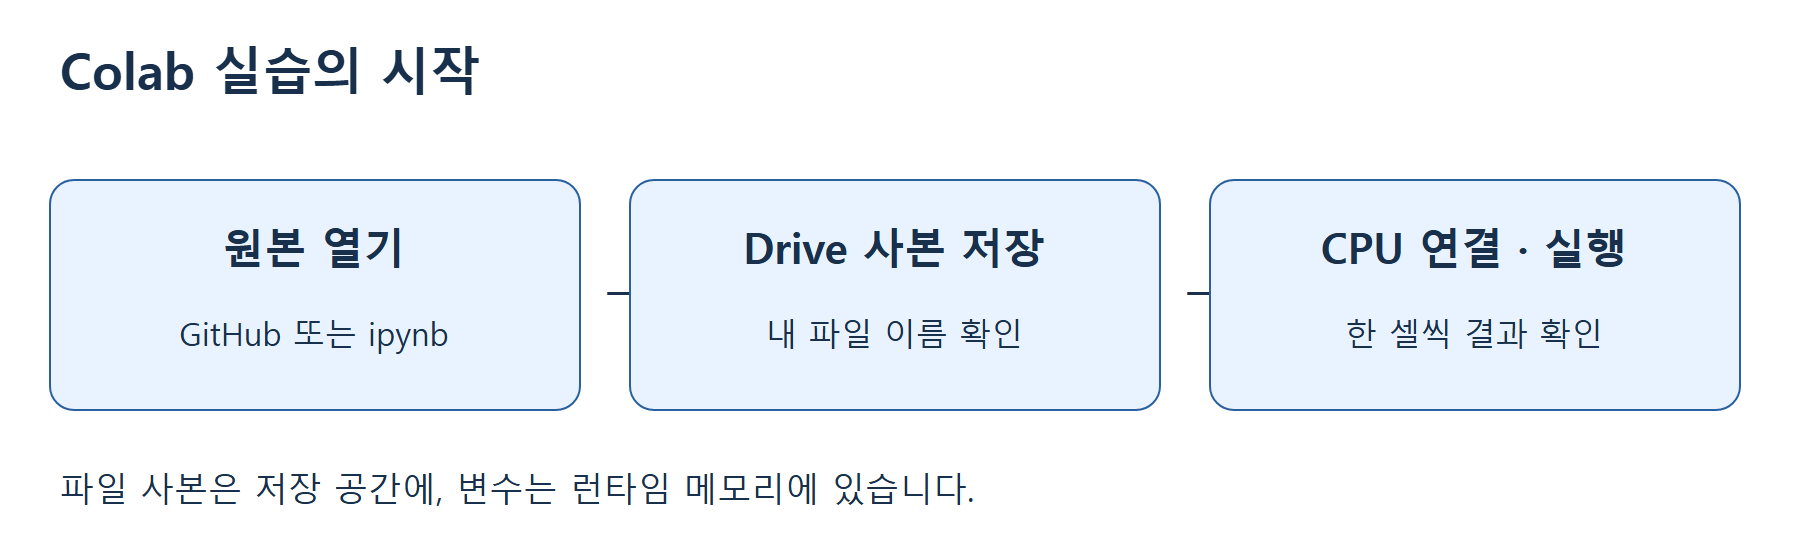

## 오늘의 목표와 준비물

오늘은 1주차의 생성형 AI 개념을 실제 코드 실행과 연결합니다. 코드를 처음부터 모두 구현하기보다 **한 셀 실행 → 결과 확인 → 입력 하나 변경 → 변화 설명**을 반복합니다.

수업을 마치면 Colab에 개인 사본을 저장하고, Python 셀을 순서대로 실행하며, seed와 생성 조건을 바꾼 실험을 기록할 수 있습니다. 인터넷이 연결된 노트북과 Google 계정을 준비합니다. 핵심 실습은 CPU로 실행하며 유료 서비스·API 키·모델 다운로드가 필요하지 않습니다.

설치·로그인이 늦어지면 이미지·오디오 중 하나부터 수행합니다.

## 1. Colab에 나의 실습 파일 만들기

1. 강의 GitHub README에서 오늘 수업의 **Colab** 링크를 누릅니다. 링크가 열리지 않으면 제공된 `.ipynb`를 다운로드한 뒤 Colab의 **파일 → 노트북 열기 → 업로드**에서 선택합니다.
2. Google 계정으로 로그인합니다. 화면 위의 제목이 `w02a-colab-generative-demo`인지 확인합니다.
3. **파일 → Drive에 사본 저장**을 선택합니다. 새 탭이 열리면 이후 작업은 그 사본에서 합니다.
4. 위쪽 파일명을 눌러 `w02a_본인이니셜.ipynb`로 바꿉니다. 학번이나 개인정보는 공개 파일명에 넣을 필요가 없습니다.
5. 오른쪽 위 **연결**을 누릅니다. 연결 뒤 RAM/Disk 표시 또는 연결된 상태가 보일 때까지 기다립니다.
6. GPU를 선택할 필요가 없습니다. 런타임 설정에서 하드웨어 가속기가 없거나 CPU인 상태로 진행합니다. 메뉴 이름은 화면 언어에 따라 다를 수 있습니다.

**확인:** 원본과 사본이 모두 열려 있다면 제목이 바뀐 사본만 남겨 둡니다. 공유된 원본에 변경 권한을 요청할 필요가 없습니다.

### 첫 코드 셀 실행

코드가 적힌 상자를 **코드 셀**이라고 합니다. 셀 왼쪽 재생 버튼을 누르거나 셀 안에서 `Shift+Enter`를 누릅니다. 아래 출력은 코드에 붙여 넣지 않습니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w02a/assets/colab-workflow.png)


## 가져다 쓰는 코드: 호출 전에 읽기

[Complete API reference](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/API.md)

### [PretrainedTextDemo · definition](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/luna_genai/pretrained_demo.py#L12)

고정 DistilGPT2를 CPU에서 한 번 로드하는 선택 시연 객체.

local_files_only: 기본 False. True이면 완전한 기존 캐시만 사용한다.
생성자에서 다운로드·모델 로딩이 발생하며 학습은 하지 않는다.
먼저 python -m luna_genai.runtime --repair-optional로 설치를 검사한다.
예: demo = PretrainedTextDemo(); demo.generate('Data science helps us').

### [PretrainedTextDemo.generate · definition](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/luna_genai/pretrained_demo.py#L37)

prompt를 포함한 영어 이어쓰기 문자열 목록을 반환한다.

prompt: 비어 있지 않은 최대 500자 문자열. max_new_tokens: 1~64, 기본40.
temperature: 양수 기본0.8. top_p: (0,1], 기본1. seed: 비음수 정수 기본42.
num_return_sequences: 1~3 정수 기본1. 모두 sampling을 사용한다.
입력은 최대256토큰이며 결과 길이는 종료 토큰으로 더 짧을 수 있다.
반환 list[str] 길이는 num_return_sequences다. 잘못된 설정은 ValueError.
같은 환경에서 seed 비교를 하며 가중치를 갱신하지 않는다.

### [prepare_text_runtime · definition](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/luna_genai/runtime.py#L15)

새 자식 Python에서 텍스트 모델 import를 검사하고 제거한 패키지 이름을 반환한다.
repair_optional: 기본 False. True인 경우에만 설치되어 있지만 import 실패한
torchvision/torchaudio/torchcodec를 현재 환경의 pip로 제거한다. 정상 선택 패키지와
torch는 유지한다. 반환 list[str]는 실제 제거 이름이며 정상 환경은 빈 목록이다.
각 import 검사 제한은 90초다. 최종 Qwen2ForCausalLM/AutoTokenizer/torch import가
실패하면 RuntimeError; 시간 초과와 pip 실패도 예외로 전달된다. 모델은 다운로드하지
않는다. 이미 해당 패키지를 불러온 notebook은 복구 후 런타임 재시작이 필요하다.
명령: python -m luna_genai.runtime --repair-optional.


In [ ]:
print("Colab 실습을 시작합니다.")
print(2 + 3)


예상 출력:

```text
Colab 실습을 시작합니다.
5
```

**직접 바꿔보기:** 첫 문장 안에 자신의 이니셜을 넣고 다시 실행합니다. 따옴표는 유지합니다. 셀을 실행하기 전 파일만 저장하면 출력은 바뀌지 않습니다.

## 2. Python 환경과 셀의 종류 확인

아래는 이후 데모에서 사용할 도구를 불러오는 셀입니다. `import`는 사용할 도구를 현재 실행 공간에 불러오는 명령입니다. 숫자로 된 버전은 친구와 조금 달라도 됩니다.


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("준비 완료")


마지막 줄에 `준비 완료`가 나오면 통과입니다. `ModuleNotFoundError`가 나면 오류에 나온 패키지명을 확인합니다. Colab 기본 환경에서 문제라면 먼저 런타임을 재시작하고 위 셀부터 다시 실행합니다. 로컬 Jupyter 사용자는 제공된 실습 의존성을 설치해야 합니다.

**텍스트 셀**은 설명과 결과 해석을 적는 곳입니다. 상단 **+ 텍스트**로 셀을 만들고 “오늘 내가 확인할 것”을 한 문장 적습니다. 코드가 설명처럼 보인다면 코드 셀인지 텍스트 셀인지 확인합니다.

## 3. 변수·목록·실행 순서 익히기

변수는 값에 붙인 이름입니다. 아래 셀은 이름과 숫자를 저장한 뒤 출력합니다. `=`는 오른쪽 값을 왼쪽 이름에 저장한다는 뜻입니다.


In [ ]:
learner = "내 이니셜"
sample_count = 5
print(learner, sample_count)


**따라 하기:** `sample_count`를 `8`로 바꾸고 실행합니다. 출력의 숫자도 `8`인지 확인합니다. 따옴표 없는 `8`은 숫자이고, `"8"`은 문자열입니다.

이번에는 여러 문자를 목록에 넣습니다. Python에서 첫 번째 위치는 0입니다.


In [ ]:
topics = ["text", "image", "audio"]
print(topics)
print(topics[0])
print(len(topics))


예상 결과는 목록, `text`, `3`입니다. `topics[1]`로 바꾸기 전에 어떤 값이 나올지 옆 사람에게 설명합니다.

### 오류를 일부러 읽어보기

아래는 코드 예시이며 기본 실행 셀에는 주석으로 들어 있습니다. 주석 `#`를 지우고 한 번 실행해 오류를 관찰한 다음, 다시 주석 처리합니다.


In [ ]:
# print(sample_counts)  # 실행해 볼 때만 맨 앞 #을 지우세요.


`NameError`가 나면 오류의 마지막 줄에서 이름을 확인합니다. 위에서 만든 이름은 `sample_count`입니다. 코드의 이름을 비교하여 고친 뒤 재실행합니다. 오류는 노트북을 망가뜨리지 않습니다.

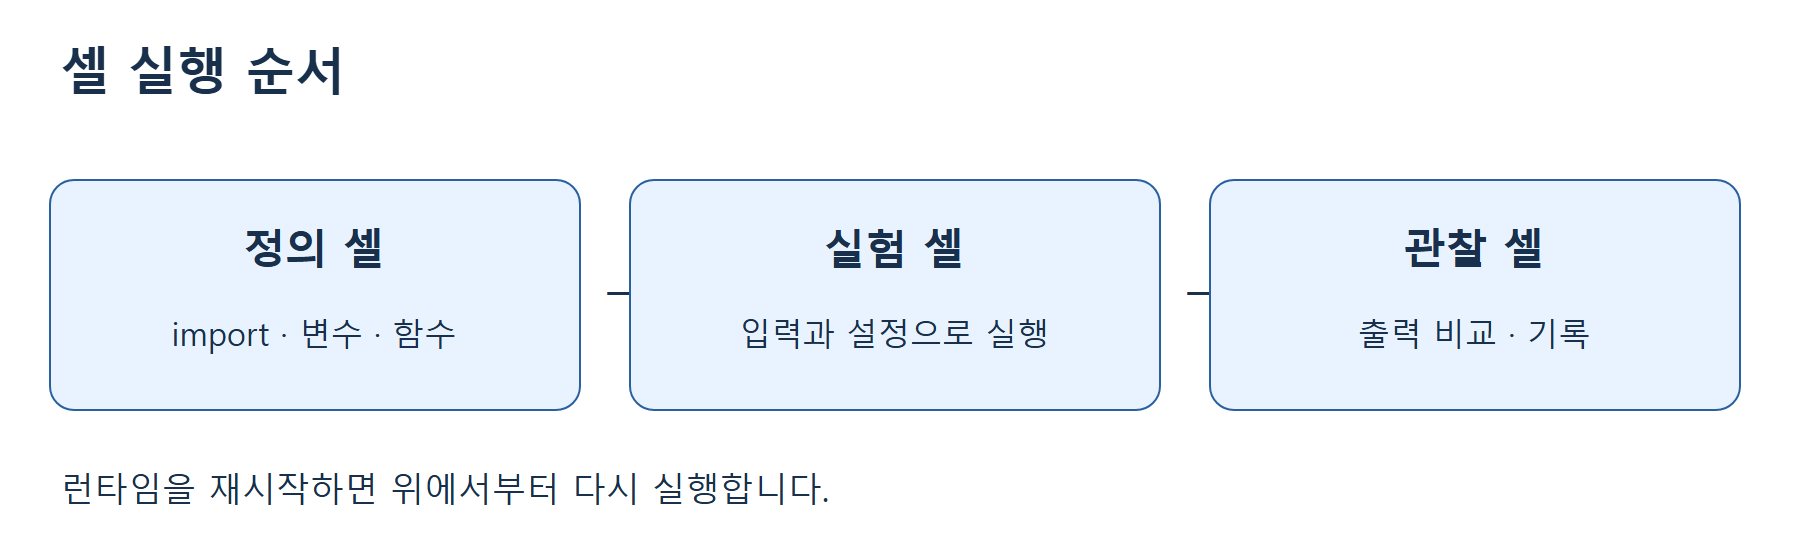

위쪽 셀에서 만든 변수는 현재 런타임의 메모리에 있습니다. 런타임이 새로 시작되면 셀을 다시 실행해야 합니다. 코드와 출력이 Drive에 저장되어 있어도 변수까지 복원되는 것은 아닙니다. 중간부터 실행해 이름 오류가 나면 필요한 위쪽 셀부터 실행합니다.

## 4. seed와 샘플링 실험

생성 모델은 후보 중 하나를 확률적으로 고를 수 있습니다. 먼저 네 후보를 뽑는 작은 실험으로 그 과정을 관찰합니다. 확률의 합은 1이어야 합니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w02a/assets/cell-order.png)


In [ ]:
words = np.array(["data", "model", "idea", "music"])
probabilities = np.array([0.50, 0.25, 0.15, 0.10])
seed = 42
rng = np.random.default_rng(seed)
draws = rng.choice(words, size=12, p=probabilities)
print(draws)
print("확률 합:", probabilities.sum())


**예상 결과:** 단어 12개와 `확률 합: 1.0`이 나옵니다. 가장 큰 확률의 `data`가 반드시 정확히 6번 나오지는 않습니다. 확률은 한 번의 추출 기회를 설명하며, 작은 표본의 개수는 달라질 수 있습니다.

1. 셀을 그대로 두 번 실행합니다. 두 배열이 같은지 확인합니다. 셀 안에서 난수 생성기를 같은 seed로 새로 만들기 때문입니다.
2. `seed = 7`로 바꾸고 실행합니다. 앞 결과와 비교합니다.
3. seed를 다시 42로 돌리고 결과가 처음과 같은지 확인합니다.
4. `rng.choice(...)`만 별도 셀에서 다시 실행하면 결과가 달라질 수 있습니다. 이미 사용한 난수 생성기의 상태가 앞으로 진행되었기 때문입니다.

### 직접 수정: 확률 오류 고치기

아래 코드는 일부러 합이 1이 아닌 후보 확률을 제시합니다. 실행이 중단되지 않도록 먼저 합만 확인합니다.


In [ ]:
my_probabilities = np.array([0.50, 0.30, 0.20, 0.10])  # TODO: 합이 1이 되도록 수정
print("현재 합:", my_probabilities.sum())
# 수정한 뒤 다음 두 줄의 주석을 해제해 확인하세요.
# my_rng = np.random.default_rng(42)
# print(my_rng.choice(words, size=12, p=my_probabilities))


**완료 조건:** 네 값이 모두 0 이상이며 합이 1이어야 합니다. 수정 이유와 가장 자주 나올 것으로 예상하는 단어를 텍스트 셀에 적습니다.

## 5. 문자 하나씩 생성하는 작은 모델

이 데모는 1주차 문자 생성기를 단순화한 **문자 bigram 모델**입니다. 짧은 문장에서 “현재 문자 뒤에 어떤 문자가 나타났는가”를 세어 다음 문자 확률을 만듭니다. 데이터로부터 확률을 추정하는 작은 통계적 생성 모델이며, Transformer나 대형 언어 모델은 아닙니다.

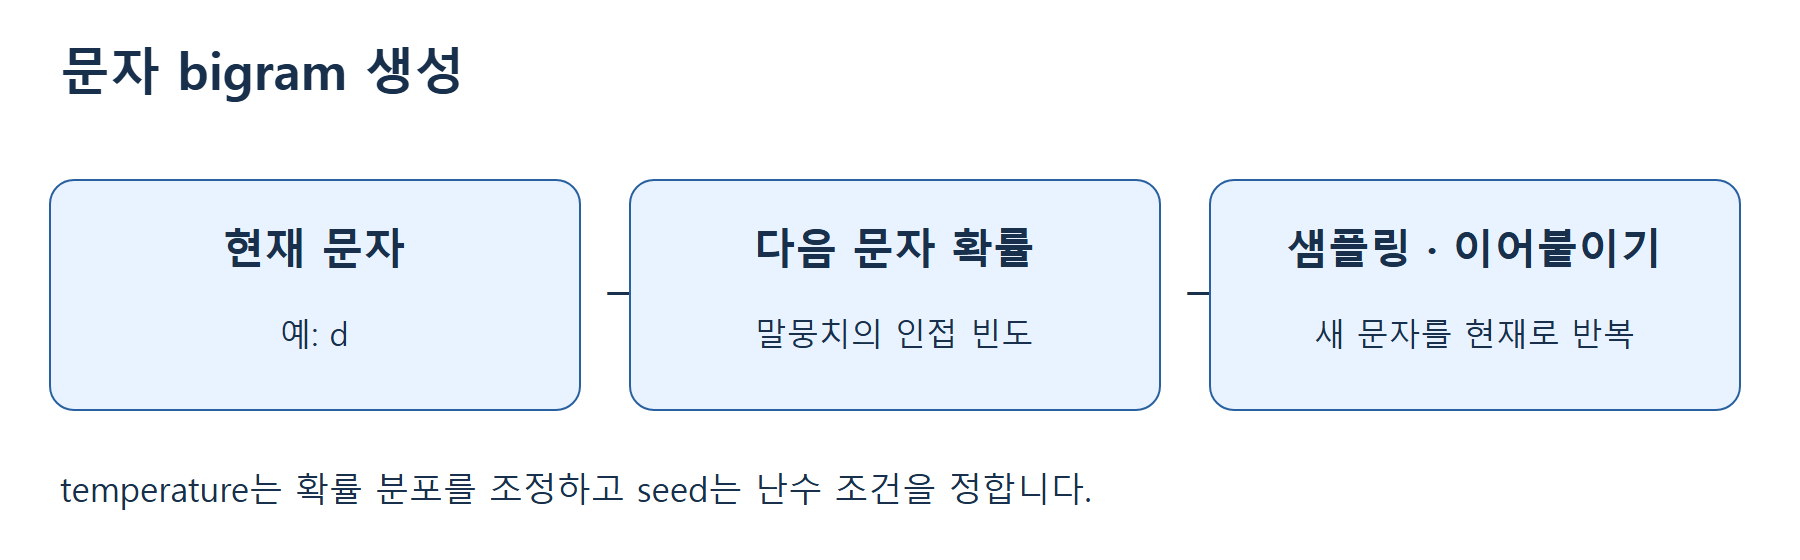

### 5-1. 학습에 쓸 작은 문장 확인

아래 문장들은 수업용으로 만든 예시입니다. 개인정보나 외부 파일을 넣지 않습니다. 반복은 자주 나온 문자 쌍의 경향을 쉽게 관찰하기 위한 장치입니다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w02a/assets/generation-loop.png)


In [ ]:
corpus = (
    "data makes ideas. models learn patterns. "
    "data models make music. ideas make art. "
) * 20
vocabulary = sorted(set(corpus))
char_index = {char: i for i, char in enumerate(vocabulary)}
counts = np.ones((len(vocabulary), len(vocabulary)))
for current, following in zip(corpus[:-1], corpus[1:]):
    counts[char_index[current], char_index[following]] += 1
transition = counts / counts.sum(axis=1, keepdims=True)
print("문자 종류:", len(vocabulary))
print("확률표 크기:", transition.shape)
print("각 행 확률 합이 1인가:", np.allclose(transition.sum(axis=1), 1))


**따라 하기:** 처음에는 그대로 실행합니다. 마지막 출력이 `True`이면 확률표가 준비되었습니다. `for`와 행렬 연산은 지금 모두 외우지 않아도 됩니다. 이 셀의 역할은 **예시 문장 → 문자 쌍 빈도 → 다음 문자 확률표**입니다. 1로 시작한 빈도는 관찰하지 못한 문자 쌍에도 작은 가능성을 남깁니다.

### 5-2. 생성 함수 준비

함수는 같은 작업을 여러 설정으로 반복하기 위한 코드 묶음입니다. 함수 정의 셀은 실행해도 생성 문장이 바로 나오지 않습니다. 아래 정의 셀을 한 번 실행하고 다음 호출 셀로 이동합니다.


In [ ]:
def generate_text(start="d", length=80, temperature=1.0, seed=42):
    """학습된 전역 transition으로 문자 bigram 문자열을 생성한다.
    start: vocabulary에 있는 문자, 기본 d. length: 시작 문자 포함 양의 정수, 기본80.
    temperature: 양수, 기본1.0. seed: 난수 초기값, 기본42.
    반환은 길이 length 문자열이다. char_index/transition/vocabulary가 먼저 필요하다.
    호출마다 새 RNG를 만들며 학습 확률표를 바꾸지 않는다. 잘못된 start/양수 조건은
    ValueError. 예: generate_text(length=25, temperature=0.5, seed=7)."""
    if start not in char_index:
        raise ValueError("start는 vocabulary에 있는 문자여야 합니다.")
    if temperature <= 0 or length < 1:
        raise ValueError("temperature와 length는 양수여야 합니다.")
    generator = np.random.default_rng(seed)
    result = [start]
    for _ in range(length - 1):
        probs = transition[char_index[result[-1]]]
        logits = np.log(probs) / temperature
        scaled = np.exp(logits - logits.max())
        adjusted = scaled / scaled.sum()
        result.append(generator.choice(vocabulary, p=adjusted))
    return "".join(result)


In [ ]:
text_a = generate_text(start="d", length=80, temperature=1.0, seed=42)
text_b = generate_text(start="d", length=80, temperature=1.0, seed=42)
print(text_a)
print("두 생성 결과가 같은가:", text_a == text_b)
print("문자 수:", len(text_a))


예상 결과는 생성 문자열, `True`, `80`입니다. 문장이 어색해도 실행 실패는 아닙니다. 이 모델은 앞 문자 하나만 보며 의미·긴 문맥·사실을 이해하지 못합니다.

### 5-3. 한 번에 한 조건만 바꾸기


In [ ]:
for temperature in [0.5, 1.0, 1.5]:
    print("temperature =", temperature)
    print(generate_text(temperature=temperature, seed=42))


낮은 temperature는 큰 확률에 더 집중하고 높은 값은 분포를 더 평평하게 만듭니다. 출력 하나만 보고 품질이 항상 좋아진다고 결론 내리지 않습니다.

**직접 실험:** 위 목록을 그대로 두고 seed만 7로 바꿉니다. 표에 seed 42와 7의 결과를 나란히 기록합니다. 다음 질문에 답합니다.

- 반복되는 부분이 어느 결과에 더 많았나요?
- 단어처럼 보이는 부분이 있어도 그 문장이 사실이라고 할 수 있나요?
- seed와 temperature를 동시에 바꾸면 무엇의 영향인지 구분하기 어려운 이유는 무엇인가요?

## 6. 이미지 표현 데모: 조건 하나 바꾸기

아래 그림은 **학습된 이미지 생성 AI가 아닌 수식·난수 기반 그림 생성기**입니다. 1주차의 절차적 이미지 데모를 간단하게 바꿨습니다. 생성 설정과 무작위성을 나누어 비교하는 연습에 사용합니다.


In [ ]:
image_seed = 42
color_style = "Blues"  # 다음에는 "Oranges"로 바꿉니다.
image_rng = np.random.default_rng(image_seed)
pixels = image_rng.random((24, 24))
plt.figure(figsize=(4, 4))
plt.imshow(pixels, cmap=color_style, vmin=0, vmax=1)
plt.title(f"seed={image_seed}, color={color_style}")
plt.axis("off")
plt.show()


1. 먼저 파란색 계열의 격자 그림이 나오는지 확인합니다.
2. seed는 그대로 두고 `color_style`만 `"Oranges"`로 바꿉니다. 밝고 어두운 칸의 위치는 같고 색상 표현만 바뀌는지 확인합니다.
3. 색상은 그대로 두고 seed만 7로 바꿉니다. 이번에는 칸별 패턴이 달라지는지 확인합니다.
4. 그림은 모델이 학습한 결과인지, 미리 정한 절차로 만든 결과인지 설명합니다.

## 7. 오디오 표현 데모: 숫자를 소리로 듣기

이 소리도 학습된 음악 생성 AI가 아닌 사인파입니다. 소리가 부담스럽다면 재생하지 않고 그래프만 확인해도 됩니다. 이어폰이나 스피커 음량을 먼저 낮춥니다.


In [ ]:
sample_rate = 16000
duration = 1.0
frequency = 440
time_axis = np.arange(int(sample_rate * duration)) / sample_rate
wave = 0.15 * np.sin(2 * np.pi * frequency * time_axis)
print("샘플 수:", len(wave))
display(Audio(wave, rate=sample_rate, normalize=False))
plt.figure(figsize=(7, 2))
plt.plot(time_axis[:160], wave[:160])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


재생 버튼을 직접 누르면 1초 소리가 납니다. 샘플 수는 16,000개입니다. `frequency`를 220으로 바꾸고 셀 전체를 재실행하면 더 낮은 소리를 듣게 됩니다. `duration`을 2로 바꾸면 샘플 수가 32,000개가 됩니다. 한 번에는 한 변수만 바꿉니다.

## 8. 선택 시연: 사전학습 언어 모델

이 부분은 교수자 안내가 있을 때만 실행합니다. 핵심 실습은 이미 끝났습니다. 기존 1주차의 선택 데모와 같은 DistilGPT2 계열을 사용합니다. 영어 문장을 이어 쓰는 사전학습 Transformer이며 한국어 대화용 모델이 아닙니다. 최초 실행에는 라이브러리와 모델 다운로드, 메모리와 추가 시간이 필요합니다.

학생 노트북의 선택 셀은 `RUN_PRETRAINED = False`입니다. 교수자가 시연할 때만 True로 바꿉니다. 다운로드가 오래 걸리거나 실패하면 이 부분을 건너뛰고 5절의 실행 결과로 비교합니다. 예시 결과를 실제 실행 결과처럼 기록하지 않습니다. 코드와 설치 방법은 노트북의 선택 셀에 있습니다.

## 9. 결과 저장과 종료 전 확인

실험 결과는 다음 틀로 텍스트 셀에 기록합니다. 긴 생성 문자열 전체 대신 일부와 자신의 해석을 적습니다.

| 실험 | 고정한 것 | 바꾼 것 | 관찰한 결과 | 내 해석 |
|---|---|---|---|---|
| 문자 생성 | 시작 문자·길이·temperature | seed | 직접 기록 | 직접 기록 |
| 문자 생성 | 시작 문자·길이·seed | temperature | 직접 기록 | 직접 기록 |
| 이미지 또는 소리 | 선택한 조건 | 한 가지 변수 | 직접 기록 | 직접 기록 |

1. 파일명이 자신의 사본인지 확인합니다.
2. 저장 상태를 확인합니다. 필요하면 **파일 → 저장** 또는 `Ctrl+S`를 누릅니다.
3. **파일 → 다운로드 → .ipynb 다운로드**로 개인 컴퓨터에도 보관합니다.
4. 과제 제출 여부와 제출 위치는 수업 공지를 따릅니다. 오늘 실습 완료 기준은 파일 보관과 결과 해석입니다.

### 막혔을 때 찾는 표

| 증상 | 확인 순서 | 복구 방법 |
|---|---|---|
| 실행 버튼이 계속 돌아감 | 연결 상태, 이전 셀 실행 여부 | 정지 버튼을 누르고 가장 단순한 첫 셀 실행 |
| NameError | 오류 이름과 위쪽 정의 비교 | 철자를 고치거나 필요한 위쪽 셀 실행 |
| SyntaxError | 따옴표·괄호·콜론·들여쓰기 | 수정한 줄을 원본과 비교 |
| 확률 합 오류 | 배열의 값과 합 | 음수 없이 합을 1로 수정 |
| 그림이 안 바뀜 | 수정 셀을 실행했는지 | 변수 설정부터 그림 셀까지 재실행 |
| 소리가 안 남 | 재생 버튼, 음량, 출력 장치 | 낮은 음량에서 다시 재생하거나 그래프 확인 |
| 새 연결 뒤 변수 없음 | 런타임 초기화 여부 | 노트북 위에서부터 다시 실행 |

## 점검 퀴즈

1. 원본 노트북을 열고 바로 수정하기보다 Drive에 사본을 저장하는 이유는 무엇인가요?
2. 노트북 파일이 저장되어 있어도 런타임 재시작 후 NameError가 날 수 있는 이유는 무엇인가요?
3. 같은 seed로 난수 생성기를 매번 새로 만든 실험을 비교하는 목적은 무엇인가요?
4. 확률이 0.5인 후보가 12번 추출에서 반드시 6번 나오나요?
5. temperature를 바꿀 때 seed와 다른 조건을 고정하는 이유는 무엇인가요?
6. 오늘의 문자 bigram 모델과 절차적 이미지 생성기는 무엇이 다른가요?
7. 16,000 Hz로 2초 오디오를 표현하면 샘플은 몇 개인가요?
8. 생성 문장이 자연스럽다는 사실만으로 사실성이 보장되지 않는 이유는 무엇인가요?

## Take-home messages

- 파일 저장과 런타임의 실행 상태는 다릅니다.
- 한 셀씩 실행하고 예상 결과와 비교하는 습관이 디버깅의 시작입니다.
- seed·입력·생성 설정을 기록하고 한 번에 한 조건을 바꿉니다.
- 샘플링 결과와 모델의 의미 이해를 혼동하지 않습니다.
- 오늘의 간단한 기준선과 사전학습 모델을 구분하여 설명합니다.

## 참고자료와 제작 근거

- 기존 1주차 강의·실습의 Colab 설정, seed, 샘플링, 문자 생성, 이미지·오디오 기준선을 재구성했습니다. 따라 하기 절차와 비교 과제, 작은 예시 코드는 이번 차시용으로 새로 작성했습니다.
- [Google Colab 공식 FAQ](https://research.google.com/colaboratory/faq.html): 노트북 저장·공유와 런타임의 차이 확인.
- [DistilGPT2 모델 카드](https://huggingface.co/distilbert/distilgpt2): 선택 시연 모델의 용도·언어·한계.
- [Transformers pipeline 안내](https://huggingface.co/docs/transformers/main/en/pipeline_tutorial): 선택 시연 API 참고.
- 주교재: 『핸즈온 생성형 AI』, 1장 생성 미디어 입문. 이번 차시에서는 추가 교재 원본을 사용하지 않았습니다.


## 선택 시연 · 사전학습 언어 모델
기본값은 실행하지 않습니다. 최초 실행 시 인터넷 연결, 패키지와 모델 다운로드가 필요합니다.
CPU에서는 수 분 이상 걸릴 수 있습니다. 영어 이어쓰기 모델이며 대화형 도우미가 아닙니다.
개인 정보는 입력하지 않습니다. 실행을 선택할 때만 아래 값을 True로 바꾸세요.
다운로드를 생략해도 필수 실습은 모두 완료됩니다.


선택 실행 API: `PretrainedTextDemo()`는 고정 DistilGPT2를 CPU에 로드한다.
`generate(prompt, max_new_tokens=40, temperature=0.8, top_p=1.0, seed=42, num_return_sequences=1)`은
prompt를 포함한 문자열 list를 반환한다. 길이는 새 토큰 수, temperature/top-p는 샘플링 설정,
seed는 난수 초기값, num_return_sequences는 생성 개수다. 처음만 다운로드하고 같은 객체를 재사용한다.
[클래스 정의와 인자 설명](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/luna_genai/pretrained_demo.py#L12).
설치 검사는 모델 파일 다운로드 전에 실행한다. 이미 import 오류가 난 런타임은 재시작한다.
기본 False를 유지하면 모델 다운로드 없이 핵심 실습을 마칠 수 있다.


In [ ]:
RUN_PRETRAINED = False
if RUN_PRETRAINED:
    import subprocess, os
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable,"-m","pip","install","-q",
            "luna-genai @ git+https://github.com/lunalab-ai/genAI.git@2026-fall-explained#subdirectory=src"],check=True)
    subprocess.run([sys.executable,"-m","luna_genai.runtime","--repair-optional"],check=True)
    from luna_genai.pretrained_demo import PretrainedTextDemo
    pretrained_demo = PretrainedTextDemo()
    outputs = pretrained_demo.generate("Data science helps us",max_new_tokens=40,
        temperature=0.8,top_p=0.95,seed=42,num_return_sequences=1)
    for output in outputs:
        print(output)
else:
    print("선택 사전학습 모델 실행을 건너뜁니다.")


In [ ]:
assert generate_text(seed=42) == generate_text(seed=42)
assert len(generate_text(length=31)) == 31
assert np.allclose(transition.sum(axis=1),1)
